# IMPORT STATEMENTS

In [1]:
import os
import json
import copy
import time
from itertools import cycle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import datasets, transforms, models
from tqdm.notebook import tqdm, trange
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# PATHS AND VARIABLES

In [2]:
DATA_DIR = "../../../data/combined-dataset-16-class"
WEIGHTS_PATH = f"{DATA_DIR}/class_weights.json"
BATCH_SIZE = 64
NUM_CLASSES = 16
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
APPLY_NOISE = False 
MODEL_NAME = "effnet_b0"

In [3]:
os.makedirs("../../../visualizations", exist_ok=True)
os.makedirs("../../../visualizations/16-class-results", exist_ok=True)
os.makedirs(f"../../../visualizations/16-class-results/{MODEL_NAME}", exist_ok=True)
visualization_path = f"../../../visualizations/16-class-results/{MODEL_NAME}"
sns.set_theme(style="whitegrid")

# SET DEVICE

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


# GAUSSIAN NOISE

In [5]:
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.05):
        self.std = std
        self.mean = mean
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

# DEFINE TRANSFORMS

In [6]:
train_transform_list = [
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]

In [7]:
if APPLY_NOISE:
    train_transform_list.append(AddGaussianNoise(mean=0.0, std=0.05))
train_transform = transforms.Compose(train_transform_list)

In [8]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# CREATE DATALOADERS

In [9]:
train_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=train_transform)
val_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=eval_transform)

In [10]:
validation_split = 0.2
dataset_size = len(train_dataset)
indices = list(range(dataset_size))
split = int(np.floor(validation_split * dataset_size))

In [11]:
np.random.seed(42)
np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

In [12]:
train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=4, pin_memory=True)

In [14]:
class_names = train_dataset.classes
print(f"Total training directory images: {dataset_size}")
print(f"Dynamically split into -> Train: {len(train_indices)} | Validation: {len(val_indices)}")

Total training directory images: 2459
Dynamically split into -> Train: 1968 | Validation: 491


# LOAD PRETRAINED EfficientNet-B0

In [15]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet-B0's classifier is a Sequential block. The linear layer is at index 1.
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)
print("Model initialized and moved to GPU.")

Model initialized and moved to GPU.


# INITIALIZE WEIGHTS

In [16]:
with open(WEIGHTS_PATH, "r") as f:
    weight_dict = json.load(f)

weights_list = [weight_dict[c] for c in class_names]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float32).to(device)

In [17]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# SET EARLY STOPPING FEATURES

In [18]:
patience = 5
best_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

In [19]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# TRAINING LOOP

In [20]:
start_time = time.time()

epoch_pbar = trange(NUM_EPOCHS, desc="Overall Progress", unit="epoch")

for epoch in epoch_pbar:
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        batch_pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [{phase.capitalize()}]", leave=False)

        for inputs, labels in batch_pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            batch_pbar.set_postfix({'batch_loss': f"{loss.item():.4f}"})

        # Calculate epoch-level metrics
        dataset_size = len(dataloader.sampler)
        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc.item())
            
            tqdm.write(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
                       f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.4f} | "
                       f"Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

    if patience_counter >= patience:
        tqdm.write(f"Early stopping triggered at epoch {epoch+1}!")
        break

time_elapsed = time.time() - start_time
print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

Overall Progress:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 2.0659 Acc: 0.3130 | Val Loss: 1.4767 Acc: 0.4297


Epoch 2 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

...

Epoch 16 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 16/30 | Train Loss: 0.5402 Acc: 0.7856 | Val Loss: 1.2041 Acc: 0.6436


Epoch 17 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 17 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 17/30 | Train Loss: 0.5251 Acc: 0.7927 | Val Loss: 1.3996 Acc: 0.6191
Early stopping triggered at epoch 17!

Training complete in 35m 25s


# LEARNING CURVE

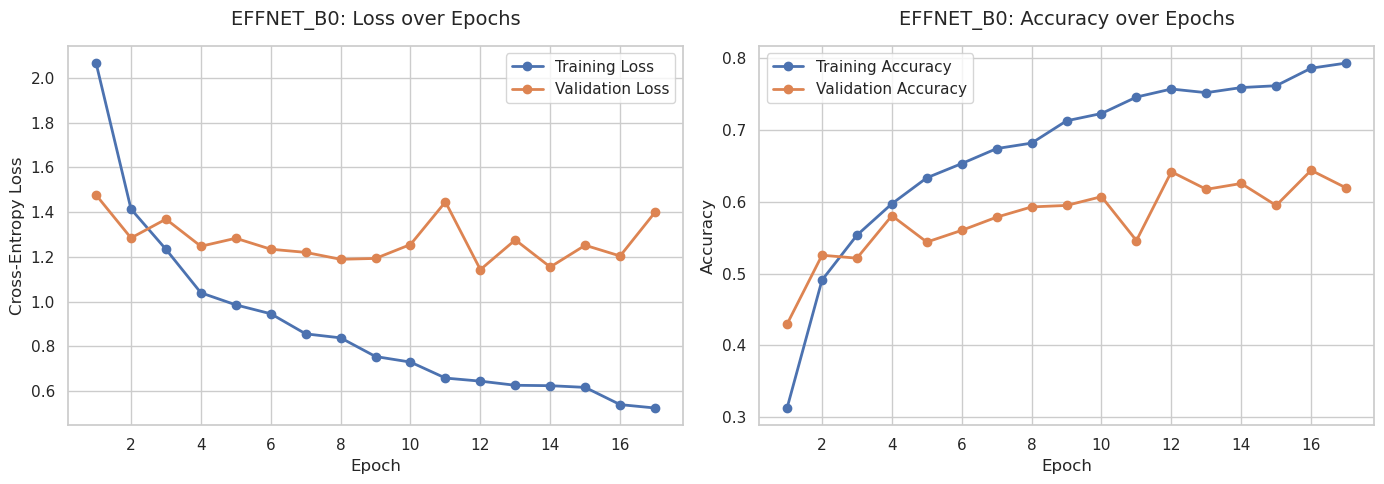

In [21]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', marker='o', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='o', linewidth=2)
plt.title(f'{MODEL_NAME.upper()}: Loss over Epochs', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=11)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accs) + 1), train_accs, label='Training Accuracy', marker='o', linewidth=2)
plt.plot(range(1, len(val_accs) + 1), val_accs, label='Validation Accuracy', marker='o', linewidth=2)
plt.title(f'{MODEL_NAME.upper()}: Accuracy over Epochs', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()

In [22]:
save_path = f"{visualization_path}/{MODEL_NAME}_learning_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Learning curves saved successfully to {save_path}")
plt.show()

Learning curves saved successfully to ../visualizations/effnet_b0/effnet_b0_learning_curve.png


<Figure size 640x480 with 0 Axes>

# SAVE BEST MODEL WEIGHTS

In [23]:
os.makedirs("../../../models", exist_ok=True)
os.makedirs("../../../models/weights-16-class", exist_ok=True)
os.makedirs(f"../../../models/weights-16-class/{MODEL_NAME}", exist_ok=True)
save_path = f"../../../models/weights-16-class/{MODEL_NAME}/{MODEL_NAME}_best.pth"
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), save_path)
print(f"Best weights saved to {save_path}")

Best model saved to ../models/effnet_b0/effnet_b0_best.pth


# TESTING

In [24]:
MODEL_WEIGHTS_PATH = f"../../../models/weights-16-class/{MODEL_NAME}/{MODEL_NAME}_best.pth"
print(f"Evaluating on device: {device}")

Evaluating on device: cuda


# DEFINE TRANSFORM

In [25]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# CREATE DATALOADER

In [26]:
test_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [27]:
class_names = test_dataset.classes
print(f"Loaded {len(test_dataset)} test images across {len(class_names)} classes.")

Loaded 322 test images across 16 classes.


# LOAD MODEL WEIGHTS

In [28]:
model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))
model = model.to(device)
model.eval()
print(f"Successfully loaded {MODEL_NAME} weights from disk.")

Successfully loaded effnet_b0 weights from disk.


/tmp/ipykernel_14809/1560799538.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))


In [29]:
all_labels = []
all_probs = []
all_preds = []

# GENERATE PREDICTIONS

In [30]:
print("Generating predictions...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Generating predictions...


# CLASSIFICATION REPORT

In [31]:
print(f"CLASSIFICATION REPORT: {MODEL_NAME.upper()}")
report_text = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report_text)

CLASSIFICATION REPORT: EFFNET_B0
                            precision    recall  f1-score   support

                Apple Leaf     1.0000    0.9000    0.9474        20
           Apple Rust Leaf     0.9000    0.8438    0.8710        32
           Apple Scab leaf     0.8065    0.7812    0.7937        32
       Corn Gray Leaf Spot     0.6000    0.6000    0.6000        15
                 Corn Leaf     1.0000    0.9091    0.9524        11
          Corn Leaf Blight     0.7143    0.6522    0.6818        23
            Corn Rust Leaf     0.8333    0.9524    0.8889        21
        Potato Leaf Blight     0.8636    0.7037    0.7755        27
     Potato Leafroll Virus     1.0000    0.5455    0.7059        11
               Tomato Leaf     0.7500    0.7895    0.7692        19
Tomato Leaf Bacterial Spot     0.4444    0.8000    0.5714        20
  Tomato Leaf Early Blight     0.4286    0.3000    0.3529        20
   Tomato Leaf Late Blight     0.7059    0.5714    0.6316        21
Tomato Leaf Po

In [32]:
with open(f"{visualization_path}/report.txt", "w") as f:
    f.write(f"Classification Report for {MODEL_NAME.upper()}\n\n")
    f.write(report_text)

In [33]:
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(f"{visualization_path}/report.csv")
print(f"Metrics saved to {visualization_path}/report.csv")

Metrics saved to ../visualizations/effnet_b0/report.csv


# CONFUSION MATRIX

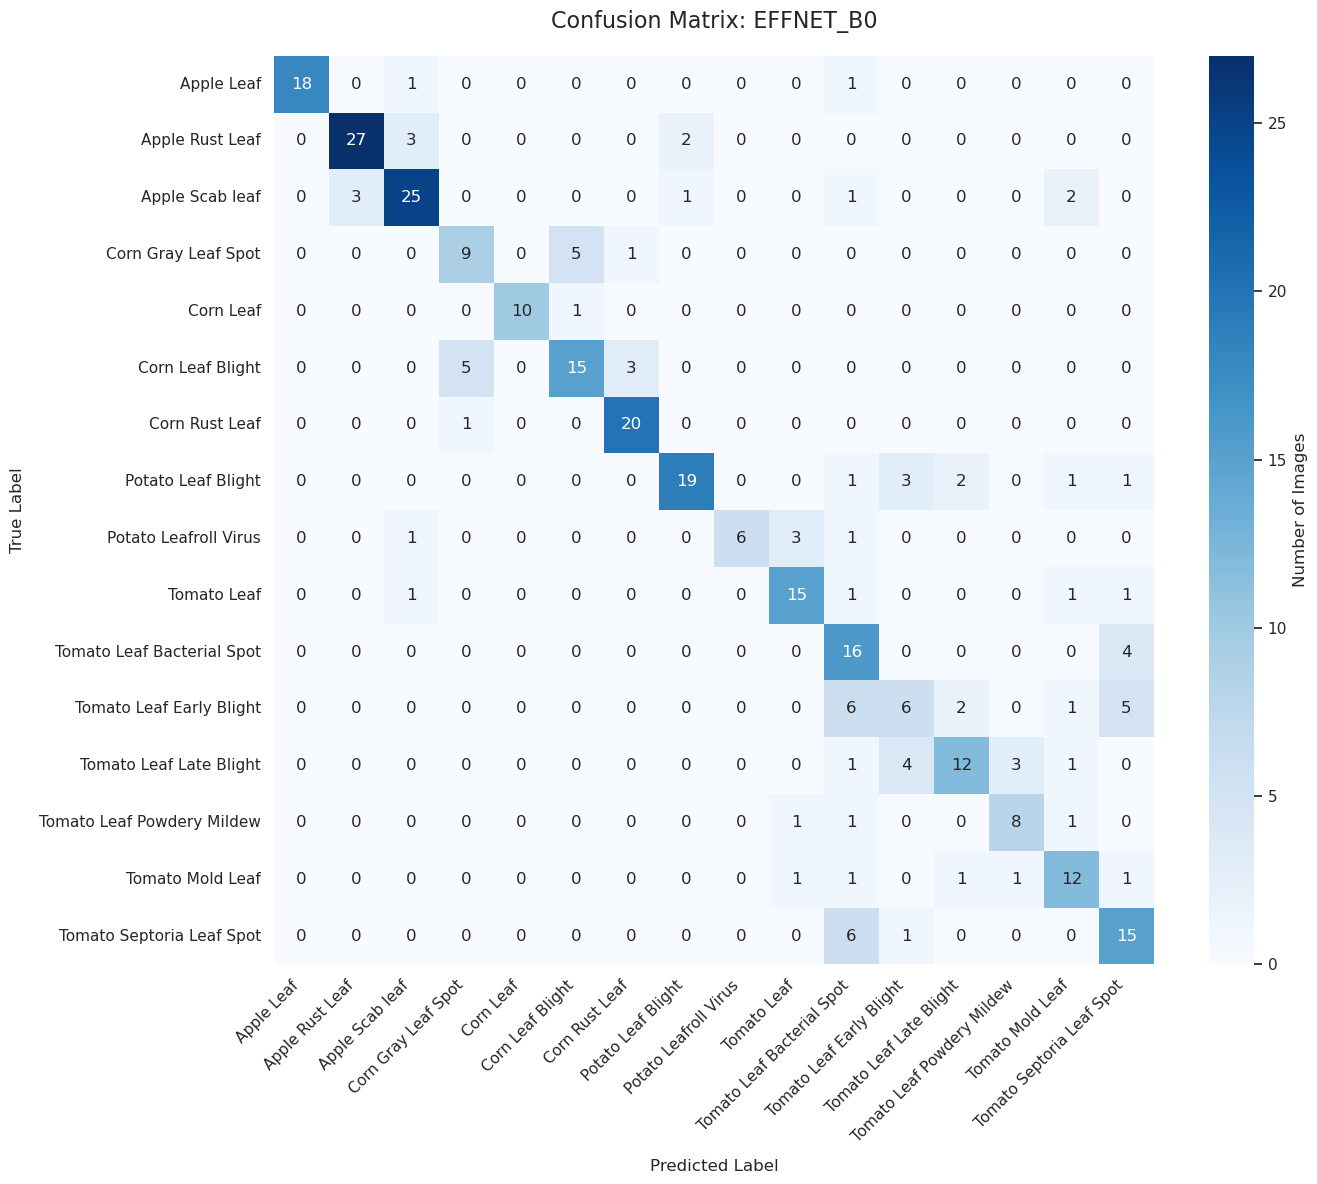

In [34]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Number of Images'})
plt.title(f'Confusion Matrix: {MODEL_NAME.upper()}', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{visualization_path}/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# AUC ROC CURVE

In [35]:
n_classes = len(class_names)
y_bin = label_binarize(all_labels, classes=range(n_classes))
all_probs = np.array(all_probs)

In [36]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

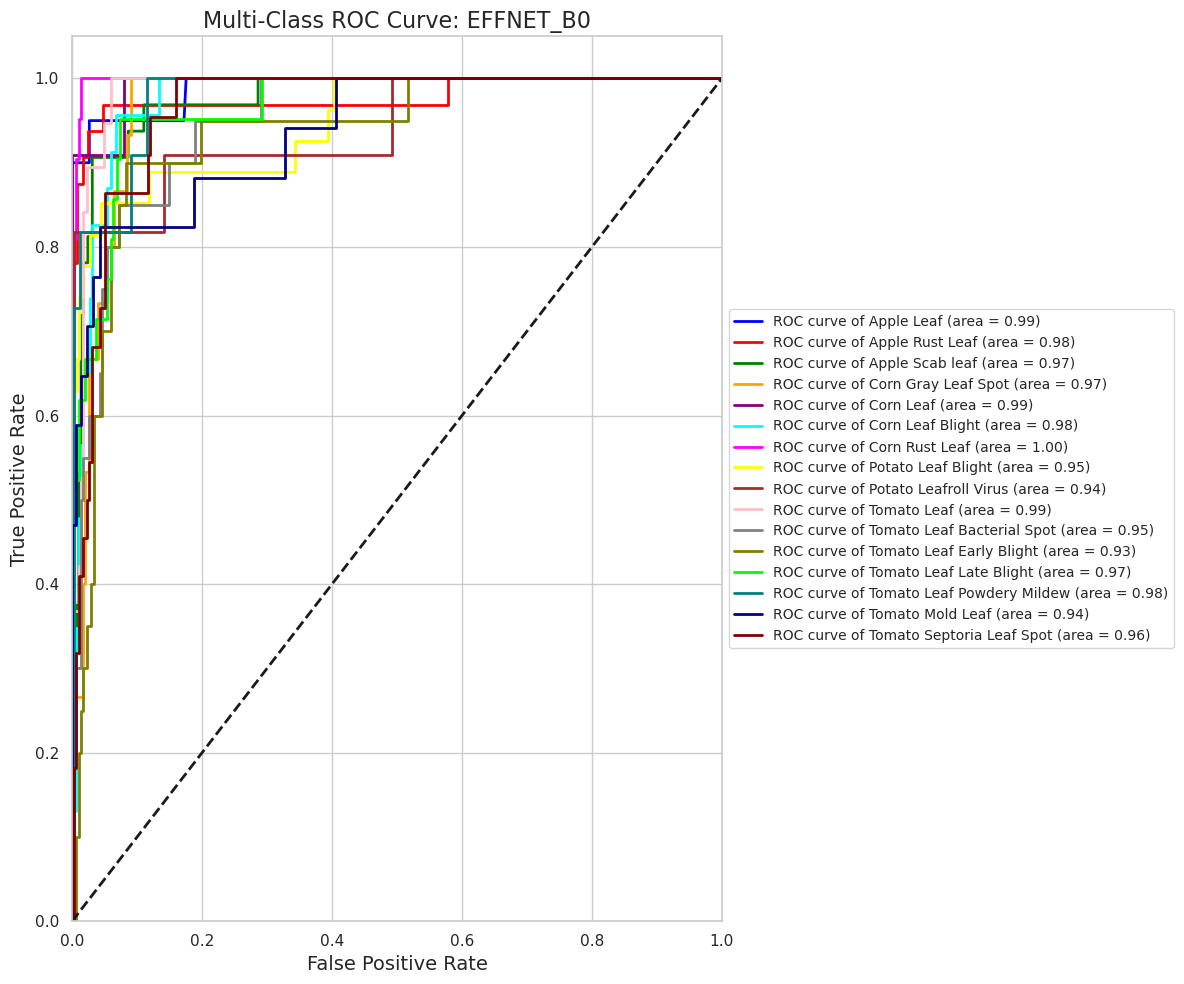

In [37]:
plt.figure(figsize=(12, 10))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink', 'gray', 'olive', 'lime', 'teal', 'navy', 'maroon'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title(f'Multi-Class ROC Curve: {MODEL_NAME.upper()}', fontsize=16)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
plt.tight_layout()
plt.savefig(f"{visualization_path}/{MODEL_NAME}_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()